# Load Images in Python

# Extract Landmarks with BlazePose(Mediapipe)

In [5]:
pip install mediapipe

In [6]:
import cv2
import os

# Path to dataset folder (change this to your dataset location)
data_dir = r"C:\Users\user\Downloads\archive (7)\Body_pose_classes"

images = []
labels = []

# Loop through each sub-folder (stand, duck, jump, etc.)
for label in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, label)
    if not os.path.isdir(folder_path):
        continue
    
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
            labels.append(label)

print("Total images loaded:", len(images))
print("Unique labels:", set(labels))

import mediapipe as mp

mp_pose = mp.solutions.pose
pose = mp_pose.Pose()
landmark_list = []
labels_list = []

for idx, img in enumerate(images):
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = pose.process(rgb_img)
    if result.pose_landmarks:
        landmarks = []
        for lm in result.pose_landmarks.landmark:
            landmarks.append([lm.x, lm.y])
        landmark_list.append(landmarks)
        labels_list.append(labels[idx])
#Load dataset — Read all images from subfolders (each folder = pose label).

#Initialize MediaPipe Pose — Set up the pose detector.

#Process images — For each image:

#Convert to RGB.

#Detect 33 body landmarks.

#Save (x, y) coordinates + label.

#Output —

#landmark_list: list of landmark coordinates per image.

#labels_list: list of corresponding pose names.


Total images loaded: 3500
Unique labels: {'kick', 'stand', 'punch', 'throw', 'power', 'jump', 'duck'}


# Convert to a CSV File

In [7]:
pip install pandas

In [8]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd

# Path to dataset
data_dir =  r"C:\Users\user\Downloads\archive (7)\Body_pose_classes" 

mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

landmark_list = []
labels_list = []

# Loop through each sub-folder (stand, duck, jump, etc.)
for label in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, label)
    if not os.path.isdir(folder_path):
        continue  # skip non-folder files

    # Loop through each image in the sub-folder
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable files

        # Convert image to RGB
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = pose.process(rgb_img)

        # Extract landmarks if found
        if result.pose_landmarks:
            landmarks = []
            for lm in result.pose_landmarks.landmark:
                landmarks.append([lm.x, lm.y])  # (x, y)
            landmark_list.append(np.array(landmarks).flatten())  # flatten 33x2 → 66
            labels_list.append(label)  # save label
            
#Reads all images from subfolders (each folder = pose label).

#Uses MediaPipe Pose to extract 33 body landmarks from each image.

#Flattens the (x, y) coordinates into a 66-value vector.

#Stores all landmark data in landmark_list and labels in labels_list.

In [9]:
# Convert to DataFrame
df = pd.DataFrame(landmark_list)
df['label'] = labels_list

# Save CSV
df.to_csv("pose_landmarks.csv", index=False)

print("CSV saved with shape:", df.shape)
print("Labels found:", set(labels_list))

#Turns all landmark data into a DataFrame.

#Adds the pose label column.

#Saves it as pose_landmarks.csv.

CSV saved with shape: (767, 67)
Labels found: {'kick', 'stand', 'punch', 'throw', 'power', 'jump', 'duck'}


# Upload into ML Model 

In [10]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plot 
%matplotlib inline 
import seaborn as sns

file_name = "pose_landmarks.csv"
df = read_csv = pd.read_csv(file_name)

print(df.head())

#loads pose_landmarks.csv into a DataFrame

          0         1         2         3         4         5         6  \
0  0.411859  0.775060  0.411287  0.769368  0.412456  0.767781  0.413653   
1  0.425403  0.728552  0.423658  0.728241  0.423558  0.727736  0.423504   
2  0.452051  0.714074  0.446192  0.712354  0.445042  0.710510  0.443958   
3  0.458026  0.742433  0.458455  0.741967  0.459071  0.742001  0.459692   
4  0.320778  0.726885  0.322206  0.723615  0.323765  0.723668  0.325343   

          7         8         9  ...        57        58        59        60  \
0  0.766230  0.407225  0.773239  ...  0.892999  0.481729  0.831789  0.390969   
1  0.727225  0.422925  0.729667  ...  0.738679  0.412580  0.767905  0.481260   
2  0.708602  0.448630  0.718384  ...  0.831791  0.414099  0.777403  0.438319   
3  0.742050  0.456587  0.741725  ...  0.727314  0.471175  0.719489  0.491256   
4  0.723696  0.316870  0.722589  ...  0.786910  0.324701  0.778269  0.285315   

         61        62        63        64        65  label  
0  0.90

In [12]:
print(f"Number of columns", df.shape[1])
print("\n Column names")
print(df.columns.tolist())

print("\n Basic Statistics")
print(df.describe())

print("\n Missing Value")
print(df.isnull().sum())


Number of columns 67

 Column names
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', 'label']

 Basic Statistics
                0           1           2           3           4           5  \
count  767.000000  767.000000  767.000000  767.000000  767.000000  767.000000   
mean     0.433214    0.573723    0.434170    0.571751    0.434279    0.571196   
std      0.151718    0.242068    0.155170    0.245503    0.155542    0.244979   
min      0.093917    0.079518    0.087071    0.079095    0.085150    0.079036   
25%      0.309352    0.333338    0.306316    0.328632    0.305817    0.328573   
50%      0.455661    0.610397    0.453652    0.608741    0.4503

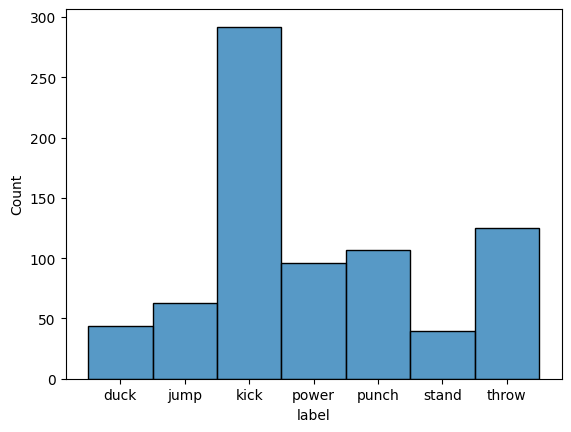

In [13]:
sns.histplot(x="label",data=df)
plot.show()
# dataset is balanced or skewed
# kick has the most samples

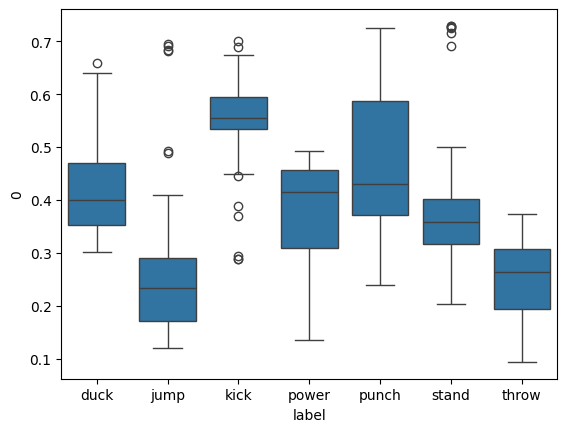

In [14]:
sns.boxplot(x="label",y=df['0'], data = df)
plot.show()

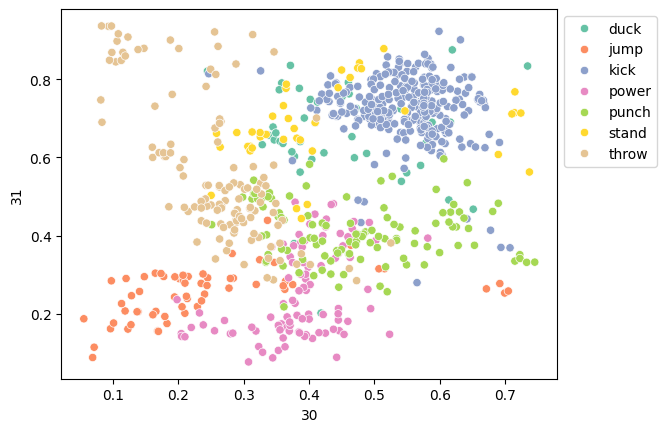

In [15]:
sns.scatterplot(x=df['30'], y=df['31'], hue=df['label'], palette='Set2')
plot.legend(bbox_to_anchor = (1,1) , loc = 2)
plot.show()


# Full Body Pose Recognition ML Pipeline

In [16]:
import sys
print(sys.executable)
# For Jupyter notebooks
import sys
!{sys.executable} -m pip install imbalanced-learn

C:\Users\user\AppData\Local\Programs\Python\Python39\python.exe


In [17]:
!pip install --upgrade scikit-learn imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [18]:
import sklearn
import imblearn
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)


scikit-learn: 1.6.1
imbalanced-learn: 0.12.4


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load your pose landmark CSV
df = pd.read_csv("pose_landmarks.csv")

# Separate features and labels
X = df.drop('label', axis=1)
y = df['label']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split into train/val/test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Data ready!")
print(f"Train samples: {X_train.shape[0]}")
print(f"Val samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# X contains all the landmark features.
# y contains the class labels for each sample.
# 7:3 ratio


Data ready!
Train samples: 536
Val samples: 115
Test samples: 116


In [20]:
# SMOTE and random forest 
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check original class distribution
print("Original class distribution:", Counter(y_train))

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Resampled class distribution:", Counter(y_train_res))

# Train your model on the resampled data
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)

# Evaluate
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print("Validation Report:\n", classification_report(y_val, y_val_pred))
print("Test Report:\n", classification_report(y_test, y_test_pred))

Original class distribution: Counter({2: 204, 6: 87, 4: 75, 3: 67, 1: 44, 0: 31, 5: 28})


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled class distribution: Counter({0: 204, 6: 204, 2: 204, 3: 204, 1: 204, 4: 204, 5: 204})
Validation Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       1.00      1.00      1.00         9
           2       0.98      0.98      0.98        44
           3       0.93      1.00      0.97        14
           4       0.94      0.94      0.94        16
           5       0.80      0.67      0.73         6
           6       1.00      0.95      0.97        19

    accuracy                           0.95       115
   macro avg       0.91      0.91      0.91       115
weighted avg       0.95      0.95      0.95       115

Test Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       1.00      1.00      1.00        10
           2       0.96      0.98      0.97        44
           3       1.00      1.00      1.00        15
  

In [21]:
import cv2
import mediapipe as mp
import numpy as np

# Load the trained model and label encoder (reuse from training)
# If you've trained them earlier in the same session, you don't need to reload.
# But if running separately, load your saved model and encoder.

# Example (optional):
# import joblib
# model = joblib.load("pose_model.pkl")
# le = joblib.load("label_encoder.pkl")

# --- Initialize Mediapipe Pose ---
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# --- Path to a test image ---
test_img_path = r"C:\Users\user\OneDrive\Pictures\power_5_test.jpg"
img = cv2.imread(test_img_path)

if img is None:
    raise ValueError("Image not found!")

# Convert to RGB
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detect landmarks
result = pose.process(rgb_img)

if result.pose_landmarks:
    landmarks = []
    for lm in result.pose_landmarks.landmark:
        landmarks.append([lm.x, lm.y])
    features = np.array(landmarks).flatten().reshape(1, -1)  # (1, 66)

    # Predict pose
    pred = model.predict(features)
    pred_label = le.inverse_transform(pred)[0]

    print("Predicted pose:", pred_label)
else:
    print("No pose landmarks detected.")


Predicted pose: power


C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
